# 🎯 OKR Tracker & Advisor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/okr-tracker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/okr-tracker/demo.ipynb)

> **OKRs get set and forgotten.** The trick isn't tracking progress — it's tracking progress *against pace*, so you catch a key result slipping while there's still a quarter left to fix it.

**Covers:** progress math (incl. decreasing targets) → pace-based status → an advisor that flags behind-pace KRs → a progress-vs-pace chart.


## Step 1 — Progress, including "lower is better" KRs

Progress is the fraction of the way from **start** to **target**. Handling decreasing targets (churn, latency) is the part people get wrong — the same formula works if you compute against the signed span.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import List

AT_RISK_GAP, OFF_TRACK_GAP = 0.10, 0.25


@dataclass
class KeyResult:
    name: str
    start: float
    current: float
    target: float
    unit: str = ""

    @property
    def progress(self) -> float:
        span = self.target - self.start
        if span == 0:
            return 1.0
        return max(0.0, min(1.0, (self.current - self.start) / span))

    def status(self, elapsed: float) -> str:
        if self.progress >= 1.0: return "done"
        gap = elapsed - self.progress
        if gap >= OFF_TRACK_GAP: return "off-track"
        if gap >= AT_RISK_GAP: return "at-risk"
        return "on-track"


churn = KeyResult("Churn rate", start=6.0, current=5.2, target=3.0, unit="%")
print(f"Churn 6.0 -> 5.2 (target 3.0): {churn.progress:.0%} done")  # decreasing target
mrr = KeyResult("MRR", 80000, 104000, 120000, "$")
print(f"MRR 80k -> 104k (target 120k): {mrr.progress:.0%} done")


Churn 6.0 -> 5.2 (target 3.0): 27% done
MRR 80k -> 104k (target 120k): 60% done


## Step 2 — Pace-based status

At 60% through the quarter, a KR at 30% isn't just "in progress" — it's **30% behind pace** and probably going to miss. Comparing progress to time-elapsed is what turns a static dashboard into an early-warning system.


In [2]:
@dataclass
class Objective:
    name: str
    key_results: List[KeyResult] = field(default_factory=list)

    @property
    def progress(self):
        return sum(k.progress for k in self.key_results) / len(self.key_results) if self.key_results else 0

    def status(self, elapsed):
        s = [k.status(elapsed) for k in self.key_results]
        if all(x == "done" for x in s): return "done"
        if "off-track" in s: return "off-track"
        if "at-risk" in s: return "at-risk"
        return "on-track"


objectives = [
    Objective("Grow revenue", [KeyResult("MRR", 80000, 104000, 120000, "$"),
                               KeyResult("Enterprise logos", 5, 7, 12)]),
    Objective("Delight users", [KeyResult("NPS", 32, 41, 50),
                               KeyResult("Churn rate", 6.0, 5.2, 3.0, "%")]),
    Objective("Ship platform", [KeyResult("Features GA", 0, 2, 8),
                               KeyResult("p95 latency", 800, 600, 300, "ms")]),
]
elapsed = 0.6
for o in objectives:
    print(f"{o.name}: {o.progress:.0%} [{o.status(elapsed)}]")
    for k in o.key_results:
        print(f"   {k.name:18} {k.progress:.0%} [{k.status(elapsed)}]")


Grow revenue: 44% [off-track]
   MRR                60% [on-track]
   Enterprise logos   29% [off-track]
Delight users: 38% [off-track]
   NPS                50% [on-track]
   Churn rate         27% [off-track]
Ship platform: 32% [off-track]
   Features GA        25% [off-track]
   p95 latency        40% [at-risk]


## Step 3 — The advisor: what to act on now

A dashboard shows status. An *advisor* tells you what to do: which KRs are behind, by how much, and whether to add focus or escalate.


In [3]:
def advise(objectives, elapsed):
    out = []
    for o in objectives:
        for k in o.key_results:
            st = k.status(elapsed)
            if st in ("at-risk", "off-track"):
                gap = elapsed - k.progress
                act = "Escalate and re-plan." if st == "off-track" else "Add focus this week."
                out.append((st, k.name, f"{k.progress:.0%} done at {elapsed:.0%} elapsed ({gap:+.0%} behind). {act}"))
    return sorted(out, key=lambda x: 0 if x[0] == "off-track" else 1)


for st, name, msg in advise(objectives, elapsed):
    print(f"[{st.upper()}] {name}: {msg}")


[OFF-TRACK] Enterprise logos: 29% done at 60% elapsed (+31% behind). Escalate and re-plan.
[OFF-TRACK] Churn rate: 27% done at 60% elapsed (+33% behind). Escalate and re-plan.
[OFF-TRACK] Features GA: 25% done at 60% elapsed (+35% behind). Escalate and re-plan.
[AT-RISK] p95 latency: 40% done at 60% elapsed (+20% behind). Add focus this week.


## Step 4 — Progress vs. pace chart

One glance: bars past the dashed pace line are safe; bars short of it are the problem.


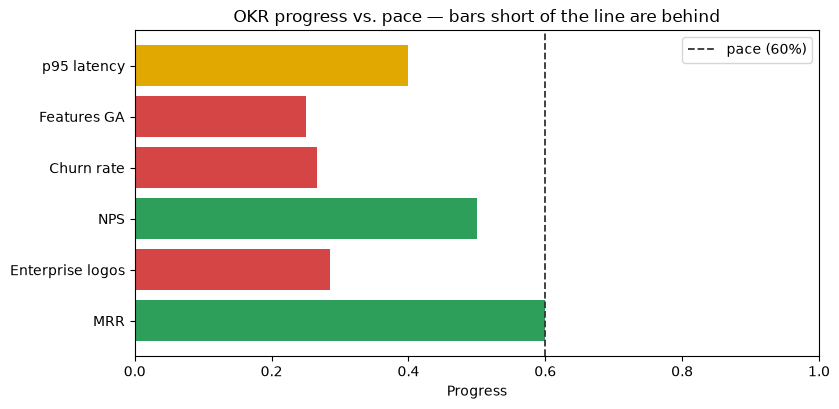

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

color = {"on-track": "#2e9e5b", "done": "#2e9e5b", "at-risk": "#e0a800", "off-track": "#d64545"}
krs = [k for o in objectives for k in o.key_results]
names = [k.name for k in krs]
vals = [k.progress for k in krs]
cols = [color[k.status(elapsed)] for k in krs]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(names, vals, color=cols)
ax.axvline(elapsed, color="#333", linestyle="--", linewidth=1.3, label=f"pace ({elapsed:.0%})")
ax.set_xlim(0, 1); ax.set_xlabel("Progress")
ax.set_title("OKR progress vs. pace — bars short of the line are behind")
ax.legend()
plt.tight_layout()
plt.savefig("okr_pace.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **Progress alone lies.** 40% done sounds fine — until you learn 70% of the quarter is gone.
- **Pace is the signal.** progress − time_elapsed is your early-warning gap.
- **Advise, don't just display.** Name the behind KRs and say escalate vs. push. That's what turns OKRs from a set-and-forget ritual into a steering tool.

The full app adds a live time-elapsed slider, per-KR progress bars, and the colored pace chart.


## Try your own OKRs

Swap in your objectives + key results and set `elapsed` to where you are in the period. Watch which KRs cross into at-risk as the quarter progresses.


In [5]:
# mine = [Objective("My objective", [KeyResult("Signups", 0, 120, 500)])]
# for st, name, msg in advise(mine, 0.75): print(st, name, msg)


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 55, Mini SaaS Products.

Streamlit version (time slider, progress bars, pace chart, advisor):
```bash
pip install -r requirements.txt
streamlit run app.py
```
